In [23]:
import os
import sys
import argparse

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [24]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [25]:
xtrain, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [26]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [27]:
def kPCA(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [28]:
def rkm_loss(output1, X):
    h, s = kPCA(output1)
    U = torch.mm(output1.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), h.t()))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), h.t())))
    f3 = 0.5 * torch.trace(torch.mm(U.t(), U))

    # Reconstruction losses
    mse = torch.nn.MSELoss()
    img_loss = mse(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim))

    f4 = img_loss

    loss = -f1 + f3 + f2 + 0.5 * (-f1 + f3 + f2) ** 2 + opt.c_accu * f4
    return loss

In [29]:
net1 = Net1(opt).double().to(opt.device)
net3 = Net3(opt).double().to(opt.device)

In [30]:
params = list(net1.parameters()) + list(net3.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)
loss_history = []

In [31]:
l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost
start = datetime.now()
global_step = 0

while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    avg_loss = 0
    for i, (datax, datay) in enumerate(xtrain):
        if i < math.ceil(opt.N / opt.mb_size):
            datax = datax.to(opt.device)
            output1 = net1(datax)

            loss = rkm_loss(output1, datax)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            global_step += 1
            avg_loss += loss.detach().cpu().numpy()
        else:
            break
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)

    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)
        
    print(t, cost)
    t += 1
    loss_history.append(cost)

print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

Finished Training in: 0:00:00.000128. Lowest cost: 6


In [32]:
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net1.load_state_dict(sd_mdl['net1_state_dict'])
#     net3.load_state_dict(sd_mdl['net3_state_dict'])

# U, h, s = final_compute_1V(opt, net1, kPCA)

In [33]:
# torch.save({'net1': net1,
#             'net3': net3,

#             'net1_state_dict': net1.state_dict(),
#             'net3_state_dict': net3.state_dict(),

#             'datax': datax,
#             'datay': datay,

#             'h': h,
#             'opt': opt, 's': s, 'U': U}, 'out/{}'.format(dirs.dirout))

In [34]:
model = torch.load('out/Final-1V.tar', weights_only=False)

U = model['U']
h = model['h']
s = model['s']

net1 = model['net1']
net3 = model['net3']

datax = model['datax']

## Evaluation

In [35]:
all_im_en = []

all_data_im = []
all_data_la = []

with torch.no_grad():
    for datax, datay in xtest:
        datax = datax.to(opt.device)
        output1 = net1(datax)
        all_im_en.append(output1.cpu())
        
        all_data_im.append(datax.cpu())
        all_data_la.append(datay.cpu())

In [36]:
all_im_en = torch.cat(all_im_en, dim=0)[:1000]

all_data_im = torch.cat(all_data_im, dim=0)[:1000]
all_data_la = torch.cat(all_data_la, dim=0)[:1000]

In [37]:
with torch.no_grad():
    h_test, _ = kPCA(all_im_en)
    U_test = all_im_en.t() @ h_test
    x_im_tilde_test = net3(h_test @ U_test.T)

In [38]:
recon_loss = torch.nn.MSELoss()

loss_im_all = recon_loss(x_im_tilde_test.view(-1, ipVec_dim), all_data_im.view(-1, ipVec_dim)).item()

print('Reconstruction loss (MSE) on test set: {:.4f}'.format(loss_im_all))

Reconstruction loss (MSE) on test set: 0.0076


## Visual Inspection

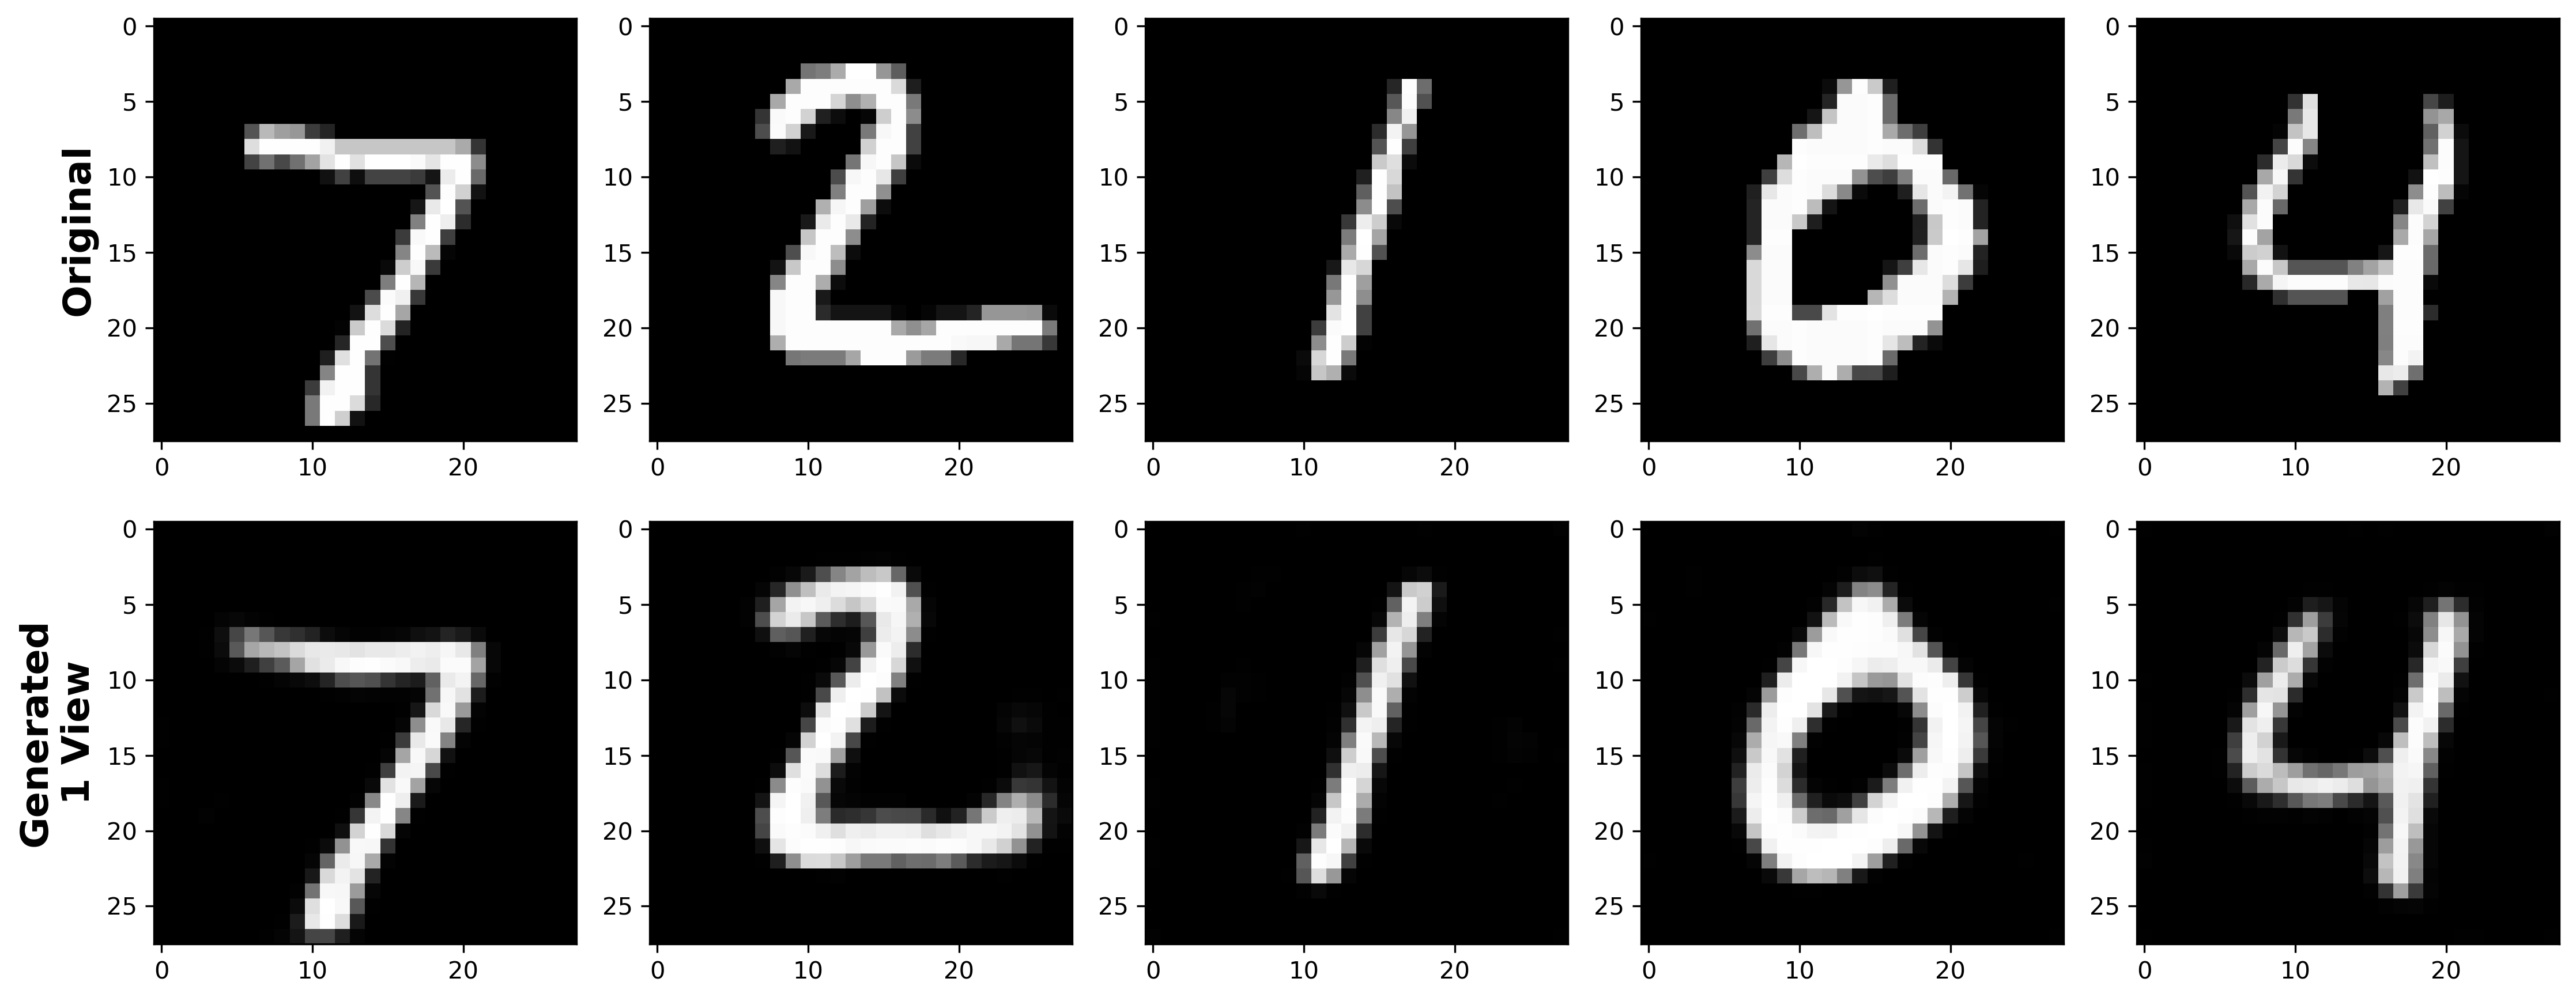

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), dpi=300)

for idx in range(5):    
    axes[0, 0].set_ylabel('\nOriginal', fontsize=16, fontweight='bold')
    axes[1, 0].set_ylabel('Generated\n1 View', fontsize=16, fontweight='bold')

    axes[0, idx].imshow(all_data_im[idx][0].reshape(28, 28), cmap='gray')

    axes[1, idx].imshow(x_im_tilde_test[idx][0].reshape(28, 28), cmap='gray')

plt.tight_layout()
plt.savefig('img/genrkm_mnist_sv_comp.png', dpi=300)
plt.show()

## Disentanglement

In [40]:
C = h_test
Z = all_data_la

factor_types = ['discrete'] * 10

In [41]:
C.shape, Z.shape

(torch.Size([1000, 24]), torch.Size([1000, 10]))

In [42]:
res = compute_dci(C, Z, factor_types, probe="lasso")
report_dci(res, title='Combined DCI Scores')

--- Combined DCI Scores ---
 > Disentanglement: 0.1255
 > Completeness: 0.1486
 > Informativeness: 0.97


- Low D & C -> Did not to learn to store digits based on value, it **organized its latent space around other factors**
- High I -> The representation did store the digits wellI men

-> Other scores must be used

## IRS

In [43]:
irs_results = compute_irs(C, Z)

print(f'--- IRS Scores ---')
print(f' > IRS Disentanglement: {round(irs_results["IRS"], 4)}')

--- IRS Scores ---
 > IRS Disentanglement: 0.4125


### MIG

In [44]:
mig_res = compute_mig(C, Z)
print(f'--- MIG Scores ---')
print(f' > MIG: {round(mig_res["MIG"], 4)}')

--- MIG Scores ---
 > MIG: 0.0601
